In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import statistics as sts
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score

In [3]:
data ={
   'sprint_feedback':['bad','good','bad','bad','good','good','bad','good'],
   'sprint_hrs':[30,40,50,30,40,20,70,80]
}

In [4]:
#100 data point hrs


In [5]:
df1=pd.DataFrame(data,columns=['sprint_hrs','sprint_feedback'])

In [6]:
df2=df1.copy()

In [7]:
df2.head(10)

,sprint_hrs,sprint_feedback
0,30,bad
1,40,good
2,50,bad
3,30,bad
4,40,good
5,20,good
6,70,bad
7,80,good


In [8]:
df2['sprint_feedback'].value_counts().to_dict()

{'bad': 4, 'good': 4}

In [9]:

df2['sprint_feedback_number']=df2['sprint_feedback'].map({'bad':0,'good':1})

In [10]:
df2.head(10)

,sprint_hrs,sprint_feedback,sprint_feedback_number
0,30,bad,0
1,40,good,1
2,50,bad,0
3,30,bad,0
4,40,good,1
5,20,good,1
6,70,bad,0
7,80,good,1


In [11]:
np.random.seed(42)
sprint_feed=['good','bad']
feedback1=np.random.choice(sprint_feed,size=10000)
hrs1=np.random.randint(low=20,high=60,size=10000)

In [12]:
d1={
    'feedback1':feedback1,
    'hrs1':hrs1
}
d2=pd.DataFrame(d1,columns=['hrs1','feedback1'])
d2.head(10)

,hrs1,feedback1
0,59,good
1,26,bad
2,51,good
3,38,good
4,25,good
5,39,bad
6,46,good
7,56,good
8,26,good
9,24,bad


In [13]:
d2['feedback1_numeric']=d2['feedback1'].map({'good':1,'bad':0})

In [ ]:
d2.sample(10)

,hrs1,feedback1,feedback1_numeric
3640,26,bad,0
9851,34,good,1
2440,28,good,1
7557,41,bad,0
155,43,bad,0
7656,22,bad,0
8807,53,good,1
2950,43,bad,0
9847,33,bad,0
3189,45,bad,0


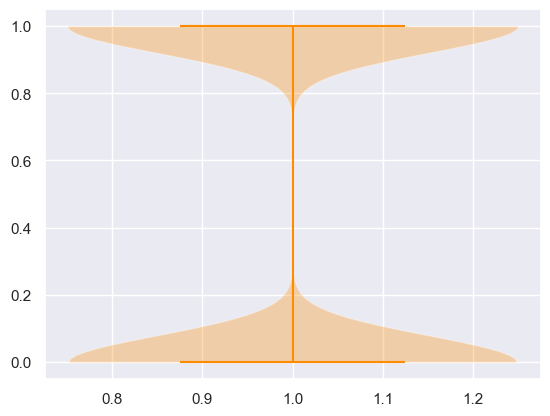

In [151]:
c1=['#ff8c00','#000000']

sns.set_palette(c1)
plt.violinplot(d2['feedback1_numeric'])
plt.grid(True)
plt.show()

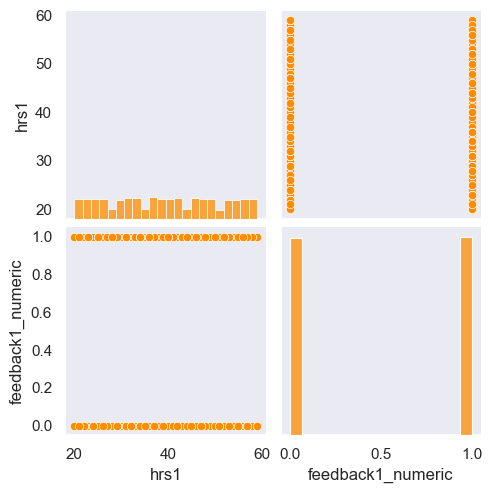

In [153]:
sns.pairplot(d2)
plt.show()

In [15]:
x1=d2['hrs1'].values.reshape(-1,1)
y1=d2['feedback1_numeric']

In [16]:
x2=d2['hrs1']

In [17]:
def outliers_detection(hrs):
    anomolies=[]
    avg=sts.mean(hrs)
    std=sts.stdev(hrs)
    normal_standard_distribution=3*sts.stdev(hrs)
    left_cutoff=sts.mean(hrs)-normal_standard_distribution
    right_cutoff=sts.mean(hrs)+normal_standard_distribution
    print(f" avg is :{avg} \n std is :{std} \n normal_standard_dis : {normal_standard_distribution} \n left_cuffoff is : {left_cutoff} \n right_cufoff  is {right_cutoff}")
    for each_anomolie in hrs:
        if each_anomolie > right_cutoff or each_anomolie < left_cutoff:
           anomolies.append(each_anomolie)
    return anomolies
result=outliers_detection(x2)
print(result)

 avg is :39.3673 
 std is :11.438062494905497 
 normal_standard_dis : 34.31418748471649 
 left_cuffoff is : 5.053112515283509 
 right_cufoff  is 73.68148748471648
[]


In [18]:
#standardscaler and minmaxscaler
new_standarrd_scaler=StandardScaler()
new_standarrd_scaler.fit_transform(x1,y1)

array([[ 1.71652163],
       [-1.16872665],
       [ 1.0170675 ],
       ...,
       [-0.20697722],
       [-0.03211369],
       [-1.60588548]], shape=(10000, 1))

In [19]:
#standardscaler and minmaxscaler
new_standarrd_scaler=MinMaxScaler()
new_standarrd_scaler.fit_transform(x1,y1)

array([[1.        ],
       [0.15384615],
       [0.79487179],
       ...,
       [0.43589744],
       [0.48717949],
       [0.02564103]], shape=(10000, 1))

In [86]:
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.1,train_size=0.9,random_state=42)

In [87]:
sprint_decision_model=LogisticRegression()
sprint_decision_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [83]:
print(x_test)

[[56]
 [47]
 [32]
 ...
 [22]
 [34]
 [33]]


In [88]:
y_pred=sprint_decision_model.predict(x_test)
print(y_pred)

[1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0
 1 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1
 1 1 1 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1
 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 1 1 0 0 0 0 0 1 1
 0 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0
 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1
 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0
 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1
 1 0 0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0
 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 1 1
 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0
 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1
 1 1 1 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 0
 1 0 1 0 1 0 0 1 0 0 0 1 

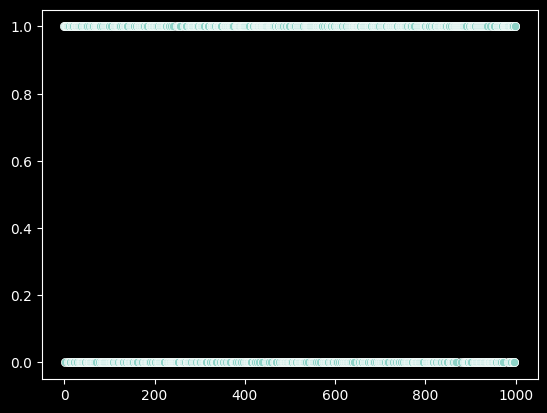

In [89]:
sns.scatterplot(y_pred)
plt.show()

In [91]:
y_pred1=sprint_decision_model.predict(x_test)
print(y_pred1)


[1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0
 1 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1
 1 1 1 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1
 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 1 1 0 0 0 0 0 1 1
 0 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0
 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1
 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0
 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1
 1 0 0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0
 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 1 1
 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0
 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1
 1 1 1 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 0
 1 0 1 0 1 0 0 1 0 0 0 1 

In [92]:
acc1=accuracy_score(y_test,y_pred1)
print(acc1)
pre=precision_score(y_test,y_pred1)
print(pre)
classi=classification_report(y_test,y_pred1)
print(classi)

0.477
0.4782608695652174
              precision    recall  f1-score   support

           0       0.48      0.45      0.46       500
           1       0.48      0.51      0.49       500

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.48      0.48      0.48      1000

